# Intent Classification

This notebook implements the intent classification module of the
RAG-based e-commerce customer support chatbot.

The Bitext customer-support dataset contains 27 detailed customer-service
intents. These intents are grouped into broader routing categories suitable
for the final chatbot:

- conversation
- order_status
- order_management
- billing_and_refunds
- account_management
- complaint
- out_of_scope

TF-IDF text features and a Linear Support Vector Classifier (LinearSVC)
are used because they provide a simple and effective supervised baseline
for short customer-support messages.

In [21]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [22]:
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})

In [23]:
df = dataset["train"].to_pandas()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [24]:
print("Number of intents:", df["intent"].nunique())

print(
    sorted(df["intent"].unique())
)

Number of intents: 27
['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']


In [25]:
intent_counts = (
    df["intent"]
    .value_counts()
    .sort_index()
)

print(intent_counts)

intent
cancel_order                 998
change_order                 997
change_shipping_address      973
check_cancellation_fee       950
check_invoice               1000
check_payment_methods        999
check_refund_policy          997
complaint                   1000
contact_customer_service    1000
contact_human_agent          999
create_account               997
delete_account               995
delivery_options             995
delivery_period              999
edit_account                1000
get_invoice                  999
get_refund                   997
newsletter_subscription      999
payment_issue                999
place_order                  998
recover_password             995
registration_problems        999
review                       997
set_up_shipping_address      997
switch_account              1000
track_order                  995
track_refund                 998
Name: count, dtype: int64


In [26]:
print("Missing values:")
print(
    df[
        ["instruction", "intent"]
    ].isnull().sum()
)

print(
    "\nDuplicate instructions:",
    df["instruction"].duplicated().sum()
)

Missing values:
instruction    0
intent         0
dtype: int64

Duplicate instructions: 2237


In [27]:
df = (
    df
    .dropna(
        subset=["instruction", "intent"]
    )
    .drop_duplicates(
        subset=["instruction"]
    )
    .reset_index(drop=True)
)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (24635, 5)


In [28]:
intent_mapping = {

    # Order status
    "track_order": "order_status",
    "delivery_options": "order_status",
    "delivery_period": "order_status",

    # Order management
    "cancel_order": "order_management",
    "change_order": "order_management",
    "place_order": "order_management",
    "change_shipping_address": "order_management",
    "set_up_shipping_address": "order_management",
    "check_cancellation_fee": "order_management",

    # Billing and refunds
    "check_invoice": "billing_and_refunds",
    "get_invoice": "billing_and_refunds",
    "check_payment_methods": "billing_and_refunds",
    "payment_issue": "billing_and_refunds",
    "check_refund_policy": "billing_and_refunds",
    "get_refund": "billing_and_refunds",
    "track_refund": "billing_and_refunds",

    # Account management
    "create_account": "account_management",
    "delete_account": "account_management",
    "edit_account": "account_management",
    "switch_account": "account_management",
    "recover_password": "account_management",
    "registration_problems": "account_management",
    "newsletter_subscription": "account_management",

    # Complaint
    "complaint": "complaint",
    "review": "complaint",

    # Requests that should be handed to a human
    "contact_customer_service": "out_of_scope",
    "contact_human_agent": "out_of_scope"
}

In [29]:
df["route_intent"] = df["intent"].map(
    intent_mapping
)

print(
    "Unmapped rows:",
    df["route_intent"].isnull().sum()
)

print(
    "\nMapped class distribution:"
)

print(
    df["route_intent"]
    .value_counts()
)

Unmapped rows: 0

Mapped class distribution:
route_intent
billing_and_refunds    6450
account_management     6442
order_management       5281
order_status           2466
out_of_scope           1999
complaint              1997
Name: count, dtype: int64


In [30]:
conversation_messages = [
    # Greetings
    "hello",
    "hi",
    "hey",
    "hello there",
    "hi there",
    "hey there",
    "good morning",
    "good afternoon",
    "good evening",
    "how are you",
    "hello support",
    "hi support team",
    "hey can you help me",
    "hello can you help me",
    "hi I need some help",
    "good morning support",
    "good evening support",
    "hello customer service",
    "hey support",
    "hi everyone",
    "hello again",
    "hey there support",
    "morning",
    "evening",
    "hi can I ask something",
    "hello I have a question",
    "hey I have a question",
    "hi I need assistance",
    "hello I need assistance",
    "good day",

    # Gratitude
    "thank you",
    "thanks",
    "thanks a lot",
    "thank you very much",
    "thanks so much",
    "many thanks",
    "I appreciate your help",
    "I really appreciate your help",
    "thanks for helping me",
    "thank you for helping me",
    "that was helpful",
    "that helped a lot",
    "great thank you",
    "great thanks",
    "thank you for your support",
    "thanks for your support",
    "I appreciate it",
    "I really appreciate it",
    "thank you so much",
    "thanks very much",
    "perfect thanks",
    "perfect thank you",
    "awesome thank you",
    "thanks that solved it",
    "thank you that solved my problem",
    "you were very helpful",
    "thanks for the assistance",
    "thank you for the assistance",
    "much appreciated",
    "thanks again",

    # Goodbye
    "goodbye",
    "bye",
    "bye bye",
    "see you",
    "see you later",
    "talk to you later",
    "have a nice day",
    "have a good day",
    "have a great day",
    "bye for now",
    "that's all thanks",
    "that is all thank you",
    "I am done thank you",
    "I am done thanks",
    "see you next time",
    "good night",
    "take care",
    "catch you later",
    "I have nothing else",
    "that's everything",
    "no more questions thanks",
    "that will be all",
    "okay bye",
    "alright goodbye",
    "thanks bye",
    "thank you goodbye",
    "thanks see you",
    "thank you see you later",
    "have a good evening",
    "have a nice evening"
]

conversation_df = pd.DataFrame({
    "instruction": conversation_messages,
    "route_intent": "conversation"
})

print("Conversation examples:", len(conversation_df))

Conversation examples: 90


In [31]:
out_of_scope_messages = [
    "what is the weather today",
    "tell me a joke",
    "who is the president",
    "write python code for me",
    "what is the capital of France",
    "help me with my homework",
    "what is machine learning",
    "give me a recipe for pizza",
    "what football team is the best",
    "play some music",
    "tell me about space",
    "how do I learn programming",
    "what time is it",
    "translate this sentence",
    "recommend a movie",
    "what is artificial intelligence",
    "how can I lose weight",
    "tell me today's news",
    "solve this math problem",
    "what is the meaning of life"
]

out_of_scope_df = pd.DataFrame({
    "instruction": out_of_scope_messages,
    "route_intent": "out_of_scope"
})

In [32]:
intent_df = pd.concat(
    [
        df[["instruction", "route_intent"]],
        conversation_df,
        out_of_scope_df
    ],
    ignore_index=True
)

print("Final dataset shape:", intent_df.shape)

print(
    intent_df["route_intent"]
    .value_counts()
)

Final dataset shape: (24745, 2)
route_intent
billing_and_refunds    6450
account_management     6442
order_management       5281
order_status           2466
out_of_scope           2019
complaint              1997
conversation             90
Name: count, dtype: int64


In [33]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(
        r"\{\{.*?\}\}",
        " entity ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [34]:
intent_df["clean_text"] = (
    intent_df["instruction"]
    .apply(clean_text)
)

intent_df[
    [
        "instruction",
        "clean_text",
        "route_intent"
    ]
].head()

,instruction,clean_text,route_intent
0,question about cancelling order {{Order Number}},question about cancelling order entity,order_management
1,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder entity,order_management
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase entity,order_management
3,I need to cancel purchase {{Order Number}},i need to cancel purchase entity,order_management
4,"I cannot afford this order, cancel purchase {{...","i cannot afford this order, cancel purchase en...",order_management


In [35]:
train_df, temp_df = train_test_split(
    intent_df,
    test_size=0.20,
    random_state=42,
    stratify=intent_df["route_intent"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["route_intent"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (19796, 3)
Validation: (2474, 3)
Test: (2475, 3)


In [36]:
print("TRAIN")
print(train_df["route_intent"].value_counts())

print("\nVALIDATION")
print(val_df["route_intent"].value_counts())

print("\nTEST")
print(test_df["route_intent"].value_counts())

TRAIN
route_intent
billing_and_refunds    5160
account_management     5153
order_management       4225
order_status           1973
out_of_scope           1615
complaint              1598
conversation             72
Name: count, dtype: int64

VALIDATION
route_intent
billing_and_refunds    645
account_management     644
order_management       528
order_status           246
out_of_scope           202
complaint              200
conversation             9
Name: count, dtype: int64

TEST
route_intent
account_management     645
billing_and_refunds    645
order_management       528
order_status           247
out_of_scope           202
complaint              199
conversation             9
Name: count, dtype: int64


In [37]:
intent_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=40000,
    sublinear_tf=True
)

X_train = intent_vectorizer.fit_transform(
    train_df["clean_text"]
)

X_val = intent_vectorizer.transform(
    val_df["clean_text"]
)

X_test = intent_vectorizer.transform(
    test_df["clean_text"]
)

y_train = train_df["route_intent"]
y_val = val_df["route_intent"]
y_test = test_df["route_intent"]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (19796, 5031)
Validation shape: (2474, 5031)
Test shape: (2475, 5031)


In [38]:
intent_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

intent_model.fit(
    X_train,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

In [39]:
val_predictions = intent_model.predict(
    X_val
)

val_accuracy = accuracy_score(
    y_val,
    val_predictions
)

print(
    "Validation Accuracy:",
    round(val_accuracy, 4)
)

print()

print(
    classification_report(
        y_val,
        val_predictions,
        digits=4
    )
)

Validation Accuracy: 0.9976

                     precision    recall  f1-score   support

 account_management     0.9969    0.9984    0.9977       644
billing_and_refunds     0.9984    0.9969    0.9977       645
          complaint     1.0000    1.0000    1.0000       200
       conversation     1.0000    0.8889    0.9412         9
   order_management     0.9981    0.9981    0.9981       528
       order_status     0.9959    0.9959    0.9959       246
       out_of_scope     0.9951    1.0000    0.9975       202

           accuracy                         0.9976      2474
          macro avg     0.9978    0.9826    0.9897      2474
       weighted avg     0.9976    0.9976    0.9976      2474



In [40]:
# Test set evaluation
test_predictions = intent_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)

print()

print(
    classification_report(
        y_test,
        test_predictions,
        digits=4
    )
)

Test Accuracy: 0.9984

                     precision    recall  f1-score   support

 account_management     0.9985    1.0000    0.9992       645
billing_and_refunds     1.0000    0.9953    0.9977       645
          complaint     1.0000    1.0000    1.0000       199
       conversation     1.0000    1.0000    1.0000         9
   order_management     0.9944    1.0000    0.9972       528
       order_status     1.0000    0.9960    0.9980       247
       out_of_scope     1.0000    1.0000    1.0000       202

           accuracy                         0.9984      2475
          macro avg     0.9990    0.9988    0.9989      2475
       weighted avg     0.9984    0.9984    0.9984      2475



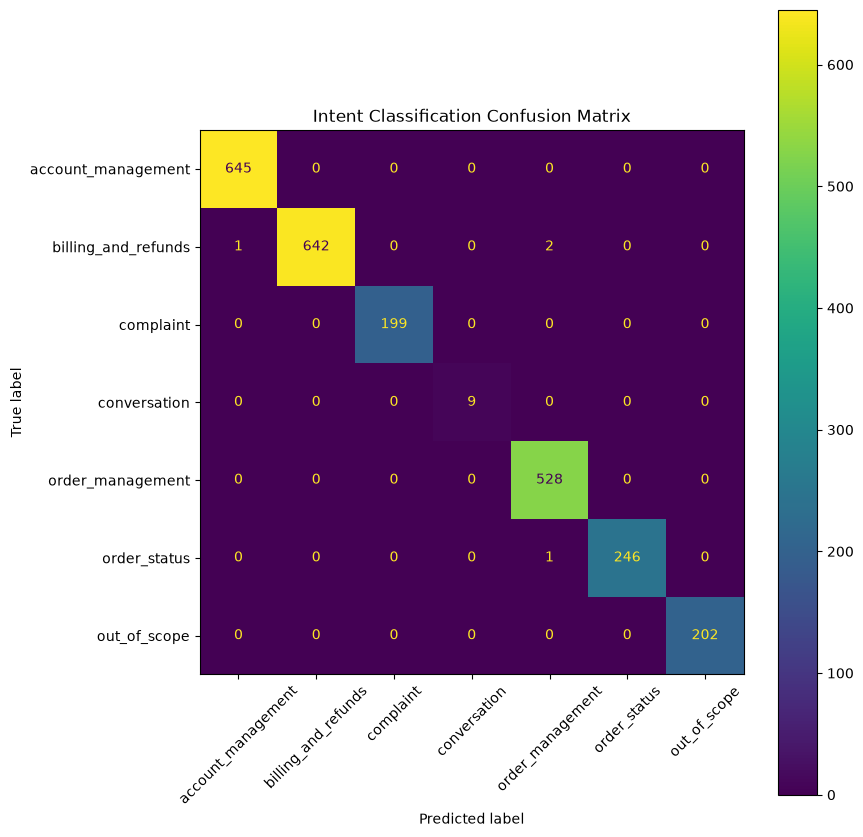

In [41]:
fig, ax = plt.subplots(
    figsize=(9, 9)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Intent Classification Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [42]:
def predict_intent(text):

    cleaned = clean_text(text)

    vector = intent_vectorizer.transform(
        [cleaned]
    )

    prediction = intent_model.predict(
        vector
    )[0]

    return prediction

In [43]:
test_messages = [
    "hello",
    "thanks for your help",
    "bye see you later",

    "where is my order",
    "when will my package arrive",
    "what delivery options do you have",

    "I want to cancel my order",
    "can I change my order",
    "I want to place a new order",

    "I need a refund",
    "why was my payment declined",
    "where can I download my invoice",

    "I forgot my password",
    "how can I delete my account",
    "I want to change my account details",

    "this service is terrible",
    "I am very disappointed with your company",

    "tell me a joke",
    "what is the weather today",
    "write python code for me"
]

for message in test_messages:

    prediction = predict_intent(
        message
    )

    print(
        f"{message} --> {prediction}"
    )

hello --> conversation
thanks for your help --> conversation
bye see you later --> conversation
where is my order --> order_status
when will my package arrive --> order_status
what delivery options do you have --> order_status
I want to cancel my order --> order_management
can I change my order --> order_management
I want to place a new order --> order_management
I need a refund --> billing_and_refunds
why was my payment declined --> billing_and_refunds
where can I download my invoice --> billing_and_refunds
I forgot my password --> account_management
how can I delete my account --> account_management
I want to change my account details --> account_management
this service is terrible --> out_of_scope
I am very disappointed with your company --> complaint
tell me a joke --> out_of_scope
what is the weather today --> out_of_scope
write python code for me --> out_of_scope


In [44]:
current_path = Path.cwd()

if current_path.name == "Jupyter notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

models_dir = project_root / "models"

print("Models directory:", models_dir)

Models directory: e:\iti\ass10\models


In [45]:
joblib.dump(
    intent_model,
    models_dir / "intent_model.pkl"
)

joblib.dump(
    intent_vectorizer,
    models_dir / "intent_vectorizer.pkl"
)

print(
    "Intent model and vectorizer saved successfully."
)

Intent model and vectorizer saved successfully.


In [46]:
loaded_intent_model = joblib.load(
    models_dir / "intent_model.pkl"
)

loaded_intent_vectorizer = joblib.load(
    models_dir / "intent_vectorizer.pkl"
)

print(
    "Intent model loaded successfully."
)

Intent model loaded successfully.


In [47]:
sample_text = "I want to track my order"

sample_cleaned = clean_text(
    sample_text
)

sample_vector = loaded_intent_vectorizer.transform(
    [sample_cleaned]
)

sample_prediction = loaded_intent_model.predict(
    sample_vector
)[0]

print(
    "Predicted intent:",
    sample_prediction
)

Predicted intent: order_status


## Conclusion

The intent classification module was implemented using TF-IDF features
and a Linear Support Vector Classifier.

The original Bitext customer-support intents were grouped into broader
routing categories suitable for the chatbot:

- conversation
- order_status
- order_management
- billing_and_refunds
- account_management
- complaint
- out_of_scope

Additional hand-labeled greeting, gratitude, goodbye, and unrelated
messages were added because these conversational cases were not well
represented in the original dataset.

The model achieved very high performance on the validation set. However,
the Bitext dataset contains many structured and similar customer-support
examples, so evaluation on custom real-world messages was also included.

The trained intent classifier and TF-IDF vectorizer were saved for
integration with the final chatbot routing pipeline.